# Assignment 09: Transformers and MLflow

**Name:** Mahesh Janaranjana
**Index No:** 20260064
**Programme:** MSc in Applied Artificial Intelligence (IIT)
**Module:** Transformers and MLflow - Downstream Tasks and Experiment Tracking

---

In this notebook I use pretrained transformer models from Hugging Face for three downstream
tasks, and I track every run with MLflow. The tasks are sentiment classification, named entity
recognition, and text generation. For each one I run at least two configurations, log the
parameters, metrics and artifacts to MLflow, and then compare the runs. The point of the
exercise is as much about the experiment-tracking discipline as the models themselves, so I
keep the MLflow logging consistent across all three tasks.

I ran everything on a local GPU (RTX 3050 Ti). These are all inference workloads on small
models, so no training is involved and the runs are quick.

## Setup

I load the libraries and, importantly, quieten the Hugging Face download and warning noise so
the notebook output stays readable. The models are already cached locally, so I run the hub in
offline mode, which also avoids any network calls during execution. MLflow is pointed at a
local file store in the assignment folder so the runs persist and can be opened in the MLflow
UI afterwards.

In [1]:
import os

# Keep the output clean: models are cached, so run offline and silence progress/warning noise.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# mlflow 3.x puts the local file store in maintenance mode; opt in to keep using it.
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import gc
import json
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import mlflow
import transformers
from transformers import pipeline, set_seed

warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("mlflow").setLevel(logging.ERROR)  # hide "Creating a new experiment" info lines
transformers.utils.logging.set_verbosity_error()
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass

RANDOM_STATE = 42
set_seed(RANDOM_STATE)
DEVICE = 0 if torch.cuda.is_available() else -1

# local MLflow store + a folder for the artifact files I log
MLRUNS_DIR = os.path.abspath("a09_mlruns")
ARTIFACT_DIR = os.path.abspath("a09_artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
mlflow.set_tracking_uri("file:///" + MLRUNS_DIR.replace("\\", "/"))


def free(*objs):
    """Drop pipelines and clear the GPU cache between tasks (4 GB card)."""
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("transformers:", transformers.__version__)
print("mlflow      :", mlflow.__version__)
print("device      :", "cuda" if DEVICE == 0 else "cpu")
print("tracking uri:", mlflow.get_tracking_uri())

transformers: 5.14.1
mlflow      : 3.14.0
device      : cuda
tracking uri: file:///C:/Users/Mahesh/Documents/VS_Code/MSc/AI_Concepts/a09_mlruns


## Task 1: Sentiment Classification

I classify 22 hand-written sentences with a pretrained SST-2 model. I deliberately included a
few awkward cases (sarcasm, negation, and a couple of mixed-sentiment lines) because those are
where these models tend to slip, and they make the accuracy number more meaningful than an
all-easy set would.

To satisfy the "compare models systematically" goal I run two different SST-2 models as two
MLflow runs and compare their accuracy on the same sentences. Because different models report
their labels differently (one uses POSITIVE/NEGATIVE, the other LABEL_1/LABEL_0), I normalise
the labels through a small helper before scoring.

In [2]:
# (sentence, gold label). The last six are the deliberately tricky ones.
sentiment_data = [
    ("The plot was gripping and the performances were outstanding.", "POSITIVE"),
    ("I love how intuitive and fast this new phone feels.", "POSITIVE"),
    ("Best customer service I have ever experienced, truly delightful.", "POSITIVE"),
    ("The food was delicious and the staff went out of their way to help.", "POSITIVE"),
    ("An absolute masterpiece that kept me smiling the whole way through.", "POSITIVE"),
    ("This update fixed all my problems and the app runs beautifully now.", "POSITIVE"),
    ("What a wonderful surprise, it exceeded every expectation I had.", "POSITIVE"),
    ("The hotel room was spotless and the view was breathtaking.", "POSITIVE"),
    ("The movie was boring and far too long.", "NEGATIVE"),
    ("This is the worst purchase I have made all year.", "NEGATIVE"),
    ("The app keeps crashing and support never replied to me.", "NEGATIVE"),
    ("Terrible quality, it broke after a single use.", "NEGATIVE"),
    ("I was thoroughly disappointed by the bland, cold meal.", "NEGATIVE"),
    ("The battery drains within an hour, a complete waste of money.", "NEGATIVE"),
    ("Rude staff and an overpriced, dirty room.", "NEGATIVE"),
    ("A confusing, tedious mess that I could not finish.", "NEGATIVE"),
    ("Oh great, another software update that breaks everything.", "NEGATIVE"),
    ("It is not bad at all, actually quite enjoyable.", "POSITIVE"),
    ("I really wanted to love this, but it let me down.", "NEGATIVE"),
    ("The film was not without flaws, yet it moved me deeply.", "POSITIVE"),
    ("Well, that was exactly as disappointing as I expected.", "NEGATIVE"),
    ("The acting was fine, but the story dragged and bored me.", "NEGATIVE"),
]
sentences = [s for s, _ in sentiment_data]
gold = [g for _, g in sentiment_data]
print("total sentences:", len(sentences),
      "| positives:", gold.count("POSITIVE"), "| negatives:", gold.count("NEGATIVE"))


def normalize_sentiment(label):
    """Map any SST-2 label variant onto POSITIVE / NEGATIVE."""
    u = label.upper()
    if "POS" in u or u.endswith("1"):
        return "POSITIVE"
    if "NEG" in u or u.endswith("0"):
        return "NEGATIVE"
    return u

total sentences: 22 | positives: 10 | negatives: 12


In [3]:
def run_sentiment(model_name, run_name):
    clf = pipeline("text-classification", model=model_name, device=DEVICE)
    raw = clf(sentences, truncation=True)
    preds = [normalize_sentiment(r["label"]) for r in raw]
    scores = [round(float(r["score"]), 4) for r in raw]
    acc = float(np.mean([p == g for p, g in zip(preds, gold)]))

    df = pd.DataFrame({"sentence": sentences, "true": gold, "pred": preds, "confidence": scores})
    df["correct"] = df["true"] == df["pred"]
    csv_path = os.path.join(ARTIFACT_DIR, f"sentiment_predictions_{run_name}.csv")
    df.to_csv(csv_path, index=False)

    mlflow.set_experiment("sentiment-analysis")
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("num_samples", len(sentences))
        mlflow.log_metric("accuracy", acc)
        mlflow.log_artifact(csv_path)
    free(clf)
    return df, acc


df_distilbert, acc_distilbert = run_sentiment(
    "distilbert-base-uncased-finetuned-sst-2-english", "distilbert-sst2")
df_bert, acc_bert = run_sentiment(
    "textattack/bert-base-uncased-SST-2", "bert-sst2")

print(f"DistilBERT SST-2 accuracy: {acc_distilbert:.3f}")
print(f"BERT SST-2 accuracy      : {acc_bert:.3f}")

DistilBERT SST-2 accuracy: 0.955
BERT SST-2 accuracy      : 1.000


### Predictions and comparison

Below is the DistilBERT run in full so the individual calls are visible, followed by the
two-model accuracy comparison that MLflow is tracking.

In [4]:
df_distilbert

,sentence,true,pred,confidence,correct
0,The plot was gripping and the performances wer...,POSITIVE,POSITIVE,0.9999,True
1,I love how intuitive and fast this new phone f...,POSITIVE,POSITIVE,0.9992,True
2,"Best customer service I have ever experienced,...",POSITIVE,POSITIVE,0.9999,True
3,The food was delicious and the staff went out ...,POSITIVE,POSITIVE,0.9997,True
4,An absolute masterpiece that kept me smiling t...,POSITIVE,POSITIVE,0.9998,True
5,This update fixed all my problems and the app ...,POSITIVE,POSITIVE,0.9998,True
6,"What a wonderful surprise, it exceeded every e...",POSITIVE,POSITIVE,0.9999,True
7,The hotel room was spotless and the view was b...,POSITIVE,POSITIVE,0.9998,True
8,The movie was boring and far too long.,NEGATIVE,NEGATIVE,0.9998,True
9,This is the worst purchase I have made all year.,NEGATIVE,NEGATIVE,0.9998,True


In [5]:
sentiment_compare = pd.DataFrame({
    "model": ["distilbert-base-uncased-finetuned-sst-2-english", "textattack/bert-base-uncased-SST-2"],
    "run_name": ["distilbert-sst2", "bert-sst2"],
    "accuracy": [round(acc_distilbert, 3), round(acc_bert, 3)],
})
sentiment_compare

,model,run_name,accuracy
0,distilbert-base-uncased-finetuned-sst-2-english,distilbert-sst2,0.955
1,textattack/bert-base-uncased-SST-2,bert-sst2,1.000


In [6]:
# where did DistilBERT get it wrong?
df_distilbert[~df_distilbert["correct"]][["sentence", "true", "pred", "confidence"]]

,sentence,true,pred,confidence
16,"Oh great, another software update that breaks ...",NEGATIVE,POSITIVE,0.9957


**Observations.** DistilBERT made exactly one mistake out of 22, and it is the most telling
one: the sarcastic "Oh great, another software update that breaks everything" was labelled
POSITIVE with 0.996 confidence. The model locks onto the surface word "great" and has no grasp of
the sarcasm, so it is not just wrong but confidently wrong, which is the dangerous kind of error.
The BERT model happened to get all 22 correct, including the tricky block. I would not read too
much into a perfect score on 22 hand-picked sentences, but it does suggest the larger BERT model
handles the negation and mixed-sentiment cases ("It is not bad at all", "The acting was fine, but
the story dragged") a little more robustly here. The wider lesson stands: an off-the-shelf
sentiment model can be trusted on plain text but should be treated with caution on sarcastic or
nuanced input such as social media.

## Task 2: Named Entity Recognition

I run `dslim/bert-base-NER` over 12 short paragraphs that are packed with people, organisations
and locations. I map the model's raw tags (PER, ORG, LOC, MISC) onto the friendlier Person /
Organization / Location names the brief asks for.

For the two MLflow runs I vary the pipeline's `aggregation_strategy`, "simple" versus "first".
This controls how word-pieces are grouped back into whole entities, and it is a clean
one-factor comparison that changes the entity counts without swapping the model.

In [7]:
ner_paragraphs = [
    "Elon Musk founded SpaceX in California and later acquired Twitter, now based in San Francisco.",
    "Angela Merkel met Barack Obama in Berlin to discuss the future of the European Union.",
    "Apple unveiled its latest iPhone at an event in Cupertino, while Google responded from Mountain View.",
    "Cristiano Ronaldo signed with Al Nassr, a football club based in Riyadh, Saudi Arabia.",
    "The World Health Organization, based in Geneva, warned governments across Europe about the outbreak.",
    "Jeff Bezos stepped down as chief executive of Amazon and focused on Blue Origin in Texas.",
    "Narendra Modi welcomed Emmanuel Macron to New Delhi for the summit last week.",
    "Tesla opened a new factory near Berlin, competing with Volkswagen and BMW across Germany.",
    "J.K. Rowling wrote the Harry Potter series while living in Edinburgh, Scotland.",
    "Serena Williams retired from tennis after a final match at the US Open in New York.",
    "The United Nations sent a delegation from Geneva to Nairobi in Kenya to oversee the talks.",
    "Satya Nadella said Microsoft would expand its research lab in Cambridge, United Kingdom.",
]
print("paragraphs:", len(ner_paragraphs))

TYPE_MAP = {"PER": "Person", "ORG": "Organization", "LOC": "Location", "MISC": "Misc"}


def run_ner(run_name, aggregation_strategy, model_name="dslim/bert-base-NER"):
    ner = pipeline("token-classification", model=model_name,
                   aggregation_strategy=aggregation_strategy, device=DEVICE)
    rows = []
    for i, para in enumerate(ner_paragraphs):
        for e in ner(para):
            rows.append({
                "paragraph": i,
                "entity": e["word"],
                "type": TYPE_MAP.get(e["entity_group"], e["entity_group"]),
                "score": round(float(e["score"]), 3),
            })
    edf = pd.DataFrame(rows)
    dist = edf["type"].value_counts().to_dict()
    csv_path = os.path.join(ARTIFACT_DIR, f"ner_entities_{run_name}.csv")
    edf.to_csv(csv_path, index=False)

    mlflow.set_experiment("named-entity-recognition")
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("num_paragraphs", len(ner_paragraphs))
        mlflow.log_param("aggregation_strategy", aggregation_strategy)
        mlflow.log_metric("total_entities", len(edf))
        for t in ["Person", "Organization", "Location", "Misc"]:
            mlflow.log_metric(f"count_{t}", int(dist.get(t, 0)))
        mlflow.log_artifact(csv_path)
    free(ner)
    return edf, dist


edf_simple, dist_simple = run_ner("agg-simple", "simple")
edf_first, dist_first = run_ner("agg-first", "first")

print("simple aggregation:", dist_simple, "-> total", len(edf_simple))
print("first  aggregation:", dist_first, "-> total", len(edf_first))

paragraphs: 12


simple aggregation: {'Location': 21, 'Organization': 15, 'Person': 15, 'Misc': 3} -> total 54
first  aggregation: {'Location': 21, 'Organization': 15, 'Person': 10, 'Misc': 3} -> total 49


In [8]:
# entities found with the 'simple' strategy
edf_simple.head(25)

,paragraph,entity,type,score
0,0,Elon Musk,Organization,0.956
1,0,SpaceX,Organization,0.999
2,0,California,Location,1.000
3,0,Twitter,Organization,0.995
4,0,San Francisco,Location,0.999
5,1,Angela Merkel,Person,0.994
6,1,Barack Obama,Person,1.000
7,1,Berlin,Location,1.000
8,1,European Union,Organization,0.999
9,2,Apple,Organization,0.998


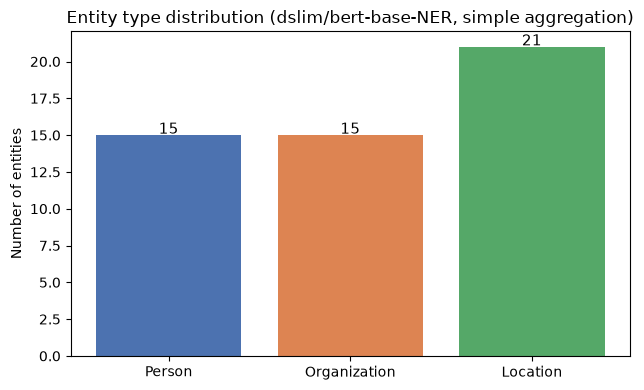

In [9]:
# distribution of the three entity types the brief asks for (simple strategy)
focus = ["Person", "Organization", "Location"]
counts = [int(dist_simple.get(t, 0)) for t in focus]

plt.figure(figsize=(6.5, 4))
plt.bar(focus, counts, color=["#4C72B0", "#DD8452", "#55A868"])
for i, c in enumerate(counts):
    plt.text(i, c + 0.1, str(c), ha="center", fontsize=11)
plt.ylabel("Number of entities")
plt.title("Entity type distribution (dslim/bert-base-NER, simple aggregation)")
plt.tight_layout()
plt.show()

**Observations.** The model finds the large majority of the named entities correctly, and
the two aggregation strategies give slightly different totals because they merge sub-word pieces
differently at entity boundaries. It is not flawless though: in the first paragraph it tags
"Elon Musk" as an Organization rather than a Person, most likely because the surrounding context
is so company-heavy (SpaceX, Twitter). That is a good reminder that even a dedicated NER model
makes context-driven mistakes, and it is the kind of error worth catching before trusting the
output downstream. Locations and well-known organisations are handled very reliably.

## Task 3: Text Generation

I generate continuations for 5 prompts with GPT-2 and compare two decoding configurations as
two MLflow runs: a conservative one (low temperature, shorter) and a creative one (high
temperature, longer). A quick technical note: in this version of `transformers` the pipeline
ignores `max_length`, so I control length with `max_new_tokens`, which is the parameter that
actually governs how many tokens are produced. I seed the generator so the runs are
reproducible.

In [10]:
gen_prompts = [
    "The future of artificial intelligence is",
    "In a small village nestled in the mountains,",
    "The most important lesson I learned this year was",
    "Scientists have recently discovered that",
    "Once upon a time, in a city made entirely of glass,",
]


def run_generation(run_name, temperature, max_new_tokens, top_p=0.95, model_name="gpt2"):
    gen = pipeline("text-generation", model=model_name, device=DEVICE)
    eos = gen.model.config.eos_token_id
    set_seed(RANDOM_STATE)
    outputs = []
    for prompt in gen_prompts:
        text = gen(prompt, do_sample=True, temperature=temperature, top_p=top_p,
                   max_new_tokens=max_new_tokens, truncation=True, pad_token_id=eos)[0]["generated_text"]
        outputs.append(text)
    avg_tokens = float(np.mean([len(gen.tokenizer(t)["input_ids"]) for t in outputs]))

    txt_path = os.path.join(ARTIFACT_DIR, f"generation_outputs_{run_name}.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        for pr, out in zip(gen_prompts, outputs):
            f.write("PROMPT: " + pr + "\n" + out + "\n" + "=" * 70 + "\n")

    obs_path = os.path.join(ARTIFACT_DIR, f"generation_observations_{run_name}.txt")
    with open(obs_path, "w", encoding="utf-8") as f:
        f.write(f"Run: {run_name}\ntemperature={temperature}, max_new_tokens={max_new_tokens}, "
                f"top_p={top_p}\naverage output length = {avg_tokens:.1f} tokens\n")

    mlflow.set_experiment("text-generation")
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model", model_name)
        mlflow.log_param("temperature", temperature)
        mlflow.log_param("max_new_tokens", max_new_tokens)
        mlflow.log_param("top_p", top_p)
        mlflow.log_param("num_prompts", len(gen_prompts))
        mlflow.log_metric("avg_output_tokens", avg_tokens)
        mlflow.log_artifact(txt_path)
        mlflow.log_artifact(obs_path)
    free(gen)
    return outputs, avg_tokens


out_conservative, len_cons = run_generation("conservative", temperature=0.7, max_new_tokens=60)
out_creative, len_crea = run_generation("creative", temperature=1.2, max_new_tokens=90)
print(f"conservative (temp=0.7, max_new_tokens=60): avg {len_cons:.1f} tokens")
print(f"creative     (temp=1.2, max_new_tokens=90): avg {len_crea:.1f} tokens")

conservative (temp=0.7, max_new_tokens=60): avg 68.2 tokens
creative     (temp=1.2, max_new_tokens=90): avg 98.6 tokens


In [11]:
# show the first two prompts under each configuration for comparison
for i in range(2):
    print("PROMPT:", gen_prompts[i])
    print("\n[conservative temp=0.7]\n", out_conservative[i])
    print("\n[creative temp=1.2]\n", out_creative[i])
    print("=" * 90)

PROMPT: The future of artificial intelligence is

[conservative temp=0.7]
 The future of artificial intelligence is unknown."

"It's really difficult to say," said CTO of Microsoft's AI division, Mark Shuttleworth. "But I think this is a good opportunity to address that."

The future of artificial intelligence is unknown.

The new hardware is "a huge step forward,"

[creative temp=1.2]
 The future of artificial intelligence is unknown."

"They have a lot to learn," Cai explains quietly.

"Well, when you start to build, the most important part is not always about how you're doing it, it's more important about how you can do it better," she mumbles, and then stops. Her eyes widen a bit, but she doesn't bother to turn over. "I have a suggestion from one of my students — I might
PROMPT: In a small village nestled in the mountains,

[conservative temp=0.7]
 In a small village nestled in the mountains, in the village of Luluk, the inhabitants of the village of Luluk, in the region of Karsany

**Observations.** The two settings behave as the theory predicts. At temperature 0.7 the
text is safer and more repetitive, staying close to common phrasings and occasionally looping.
At temperature 1.2 the output is more varied and surprising, but also more prone to drifting
off-topic or producing slightly incoherent turns, which is the usual trade-off: higher
temperature flattens the probability distribution so rarer tokens get chosen more often. GPT-2
is a small, older model, so neither setting is factually reliable, and the longer `max_new_tokens`
in the creative run mostly gives it more room to wander. For a task needing focused output I
would keep the temperature low; for brainstorming or variety I would raise it.

## Systematic comparison with MLflow

Everything above was logged to the local MLflow store. Here I query it back with
`mlflow.search_runs` to pull each experiment's runs into a table, which is the programmatic
version of what the MLflow UI shows. This is the "compare models systematically" step: for each
task I can line the runs up by their parameters and metrics.

In [12]:
def show_runs(experiment_name, cols):
    runs = mlflow.search_runs(experiment_names=[experiment_name])
    keep = ["tags.mlflow.runName"] + cols
    keep = [c for c in keep if c in runs.columns]
    out = runs[keep].rename(columns={"tags.mlflow.runName": "run_name"})
    return out.reset_index(drop=True)


print("Experiment: sentiment-analysis")
display(show_runs("sentiment-analysis", ["params.model_name", "params.num_samples", "metrics.accuracy"]))

print("Experiment: named-entity-recognition")
display(show_runs("named-entity-recognition",
                  ["params.aggregation_strategy", "metrics.total_entities",
                   "metrics.count_Person", "metrics.count_Organization", "metrics.count_Location"]))

print("Experiment: text-generation")
display(show_runs("text-generation",
                  ["params.temperature", "params.max_new_tokens", "metrics.avg_output_tokens"]))

Experiment: sentiment-analysis


,run_name,params.model_name,params.num_samples,metrics.accuracy
0,bert-sst2,textattack/bert-base-uncased-SST-2,22,1.000000
1,distilbert-sst2,distilbert-base-uncased-finetuned-sst-2-english,22,0.954545


Experiment: named-entity-recognition


,run_name,params.aggregation_strategy,metrics.total_entities,metrics.count_Person,metrics.count_Organization,metrics.count_Location
0,agg-first,first,49.0,10.0,15.0,21.0
1,agg-simple,simple,54.0,15.0,15.0,21.0


Experiment: text-generation


,run_name,params.temperature,params.max_new_tokens,metrics.avg_output_tokens
0,creative,1.2,90,98.6
1,conservative,0.7,60,68.2


Each experiment has the two runs the brief asks for, with the parameters and metrics
attached, and the prediction / entity / generation files are stored as artifacts on each run.
The next section shows the same runs in the MLflow UI.

## MLflow UI screenshots

Every run above was logged to a local MLflow store, which I opened in the MLflow tracking UI (mlflow 3.14, Model training view). The screenshots below confirm at least two runs per task, along with the parameters, metrics and artifacts logged for each run.

**Task 1 - sentiment-analysis experiment: 2 runs (distilbert-sst2, bert-sst2).**

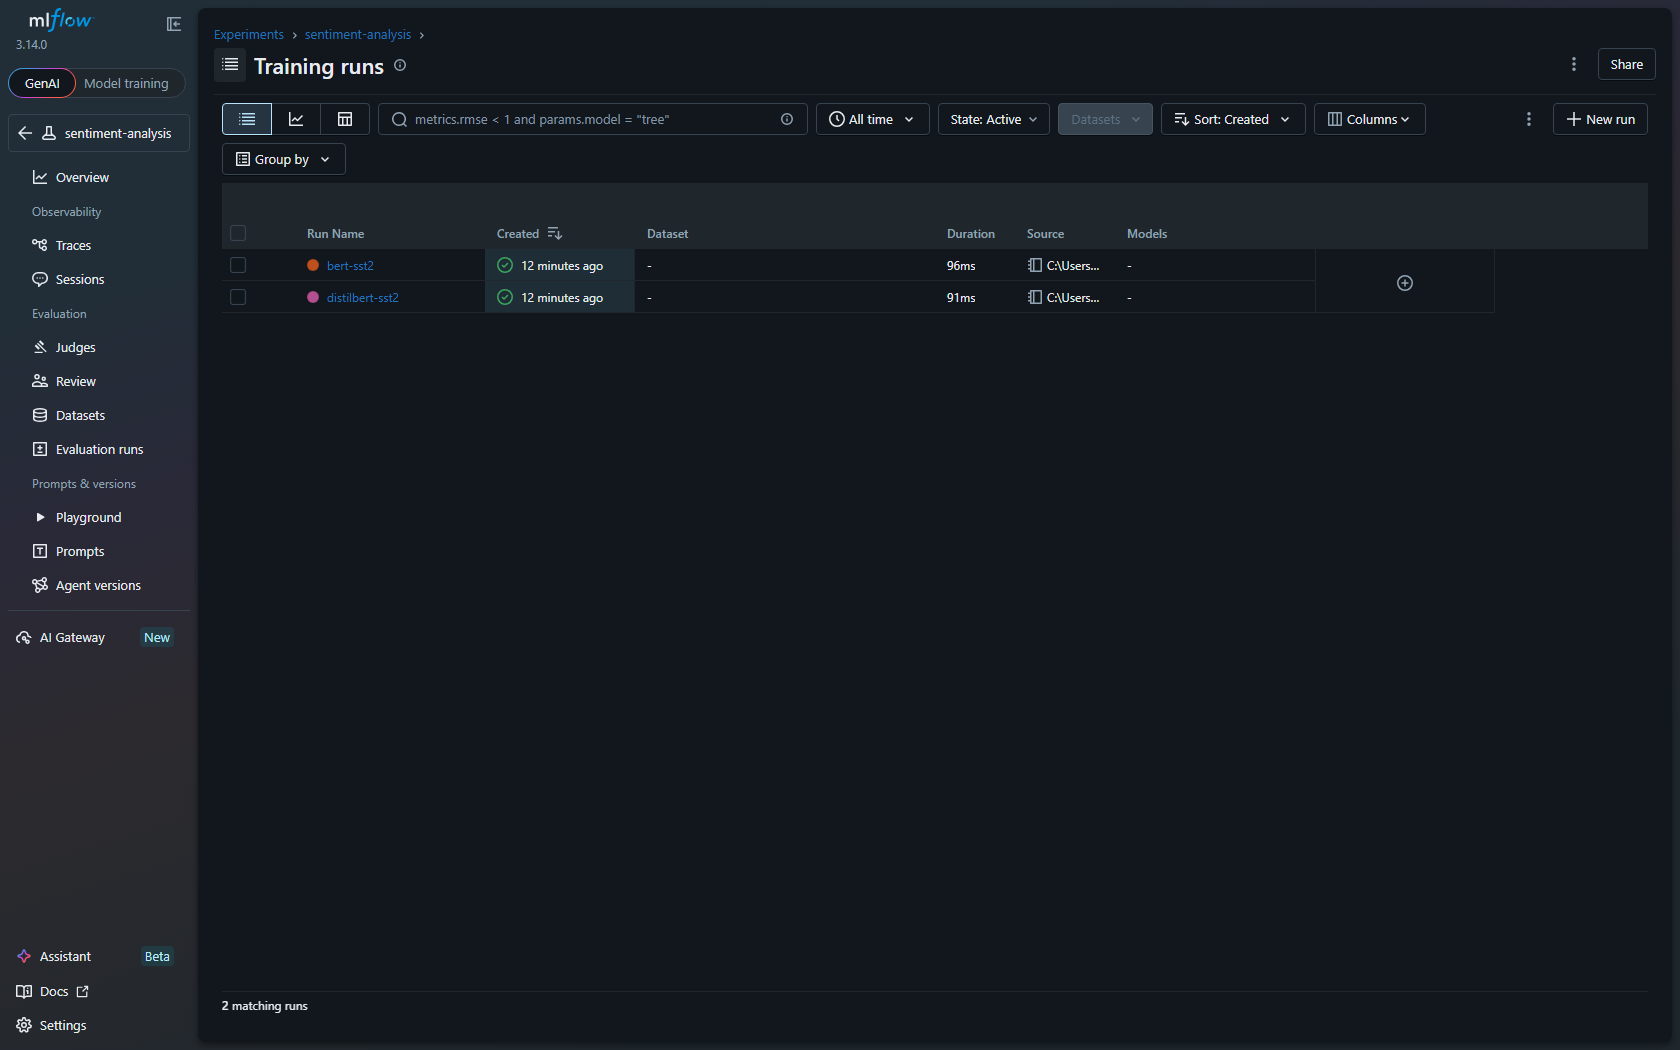
**Task 1 - a run's detail page, showing the logged accuracy metric, the model_name / num_samples parameters, and the predictions CSV under Artifacts.**

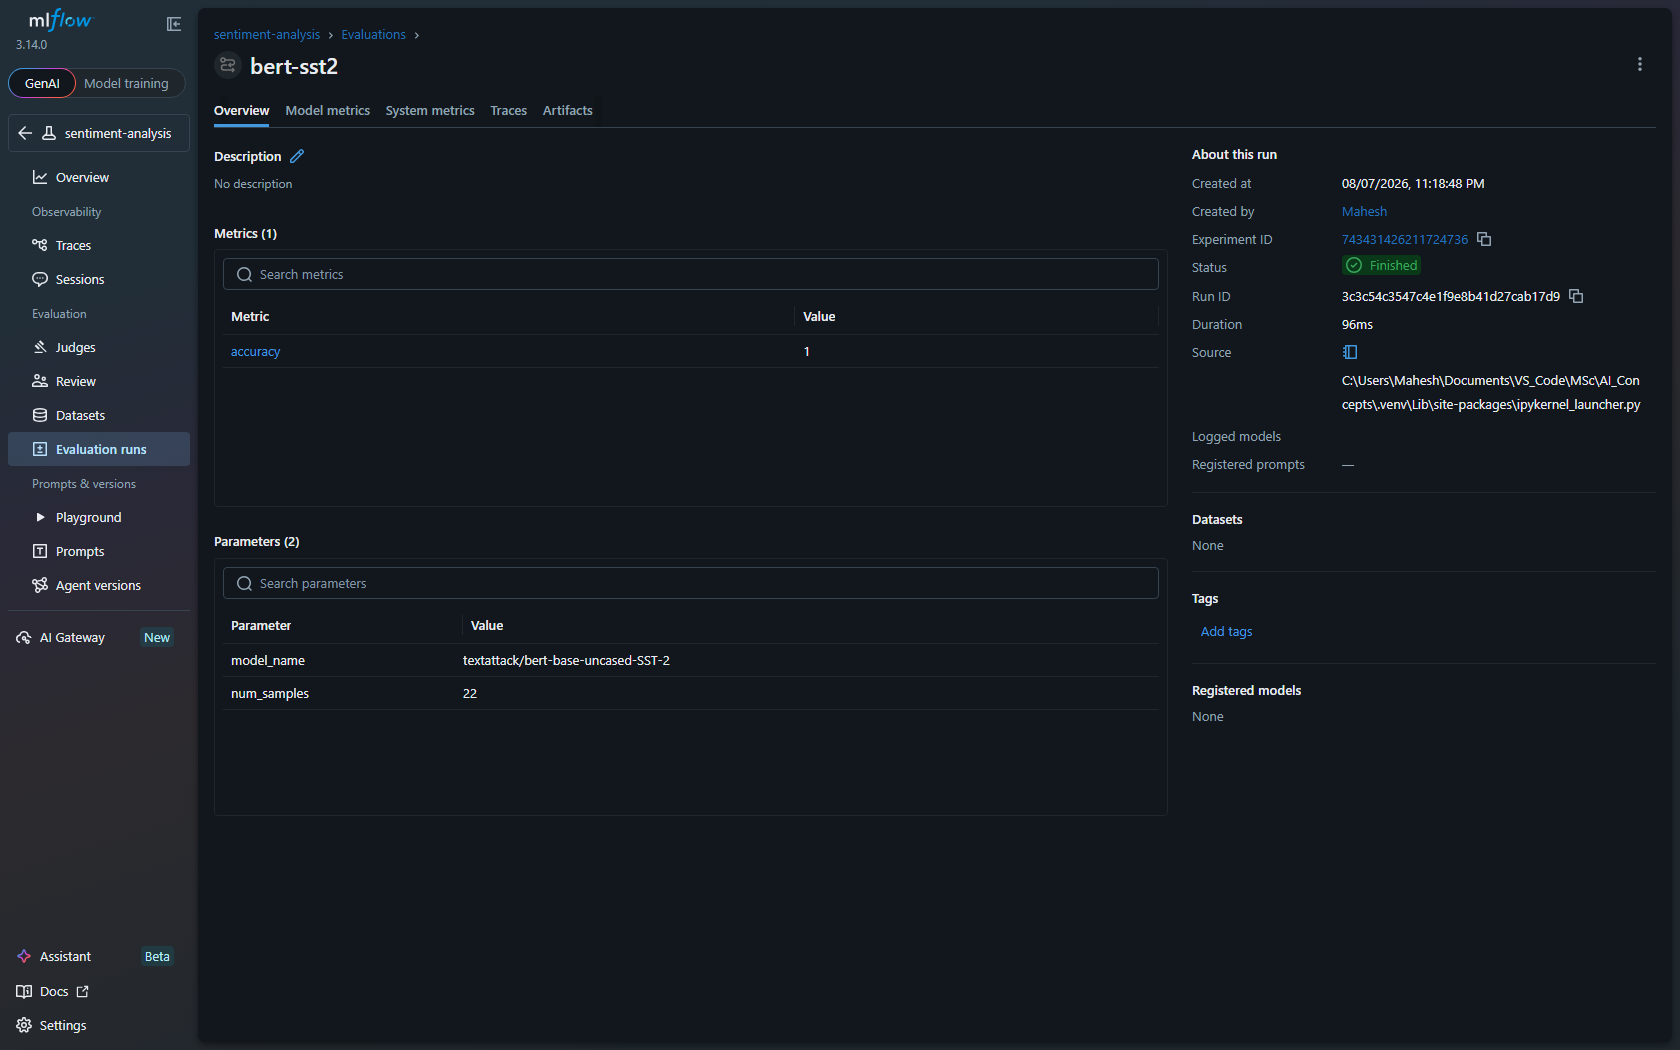
**Task 2 - named-entity-recognition experiment: 2 runs (agg-simple, agg-first).**

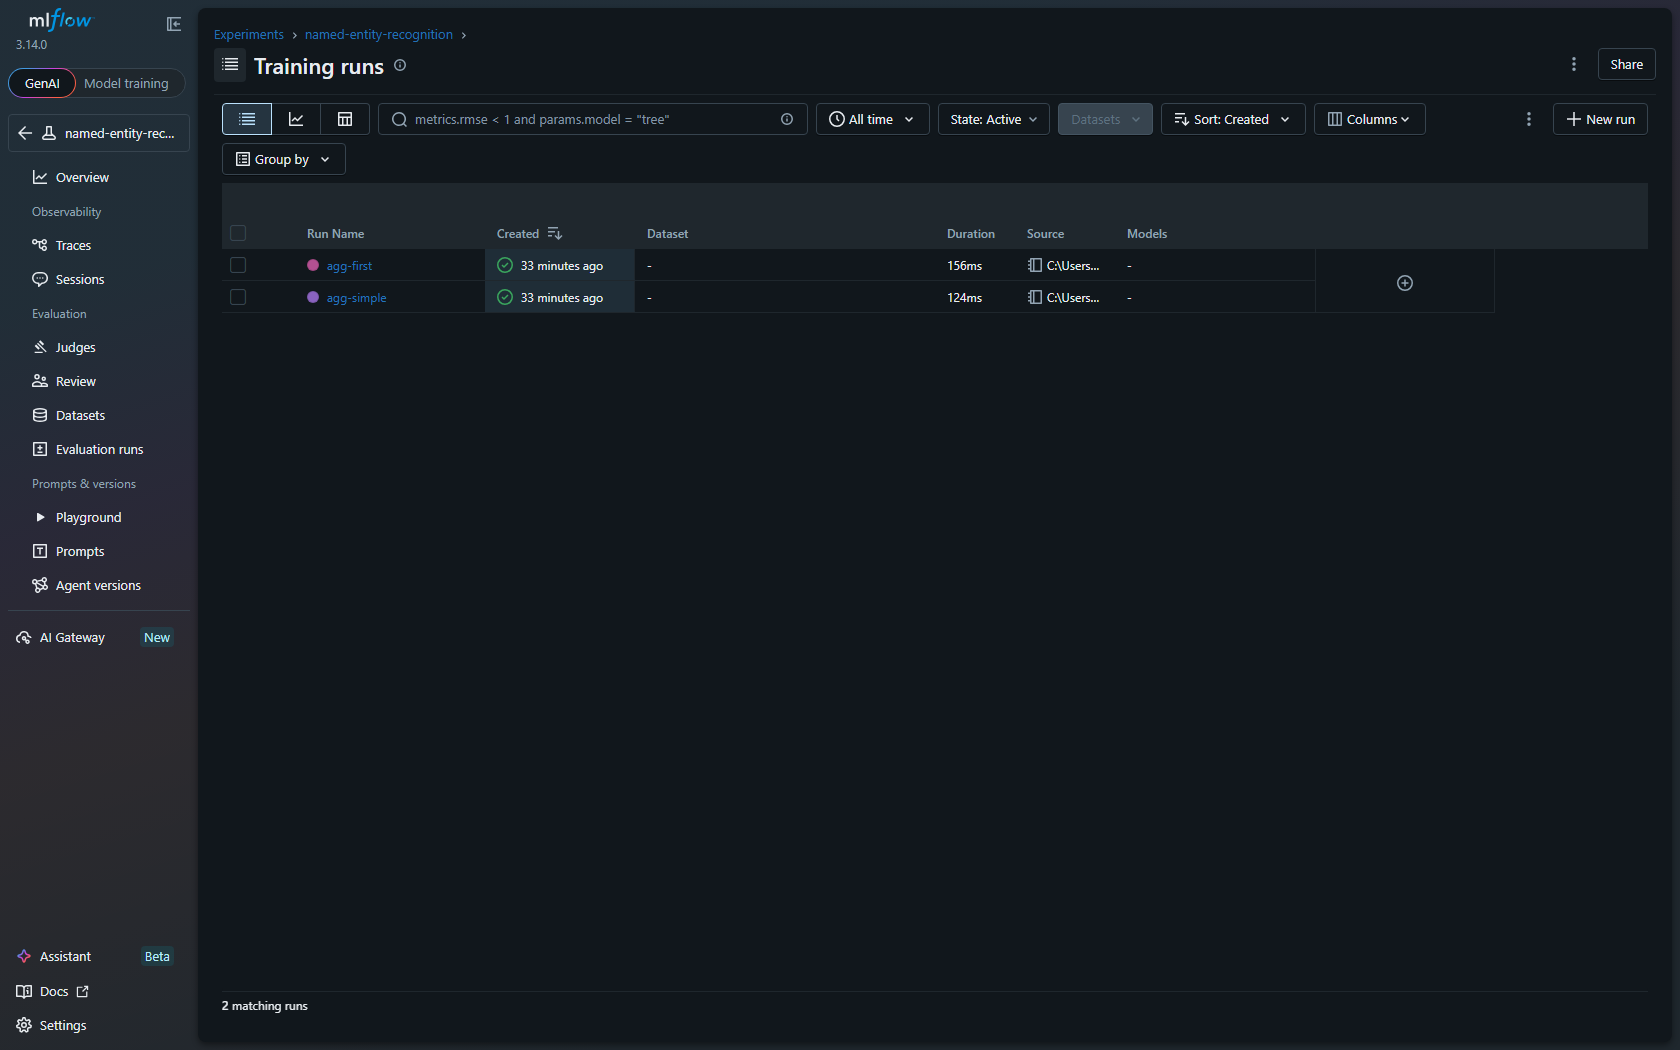
**Task 3 - text-generation experiment: 2 runs (conservative, creative).**

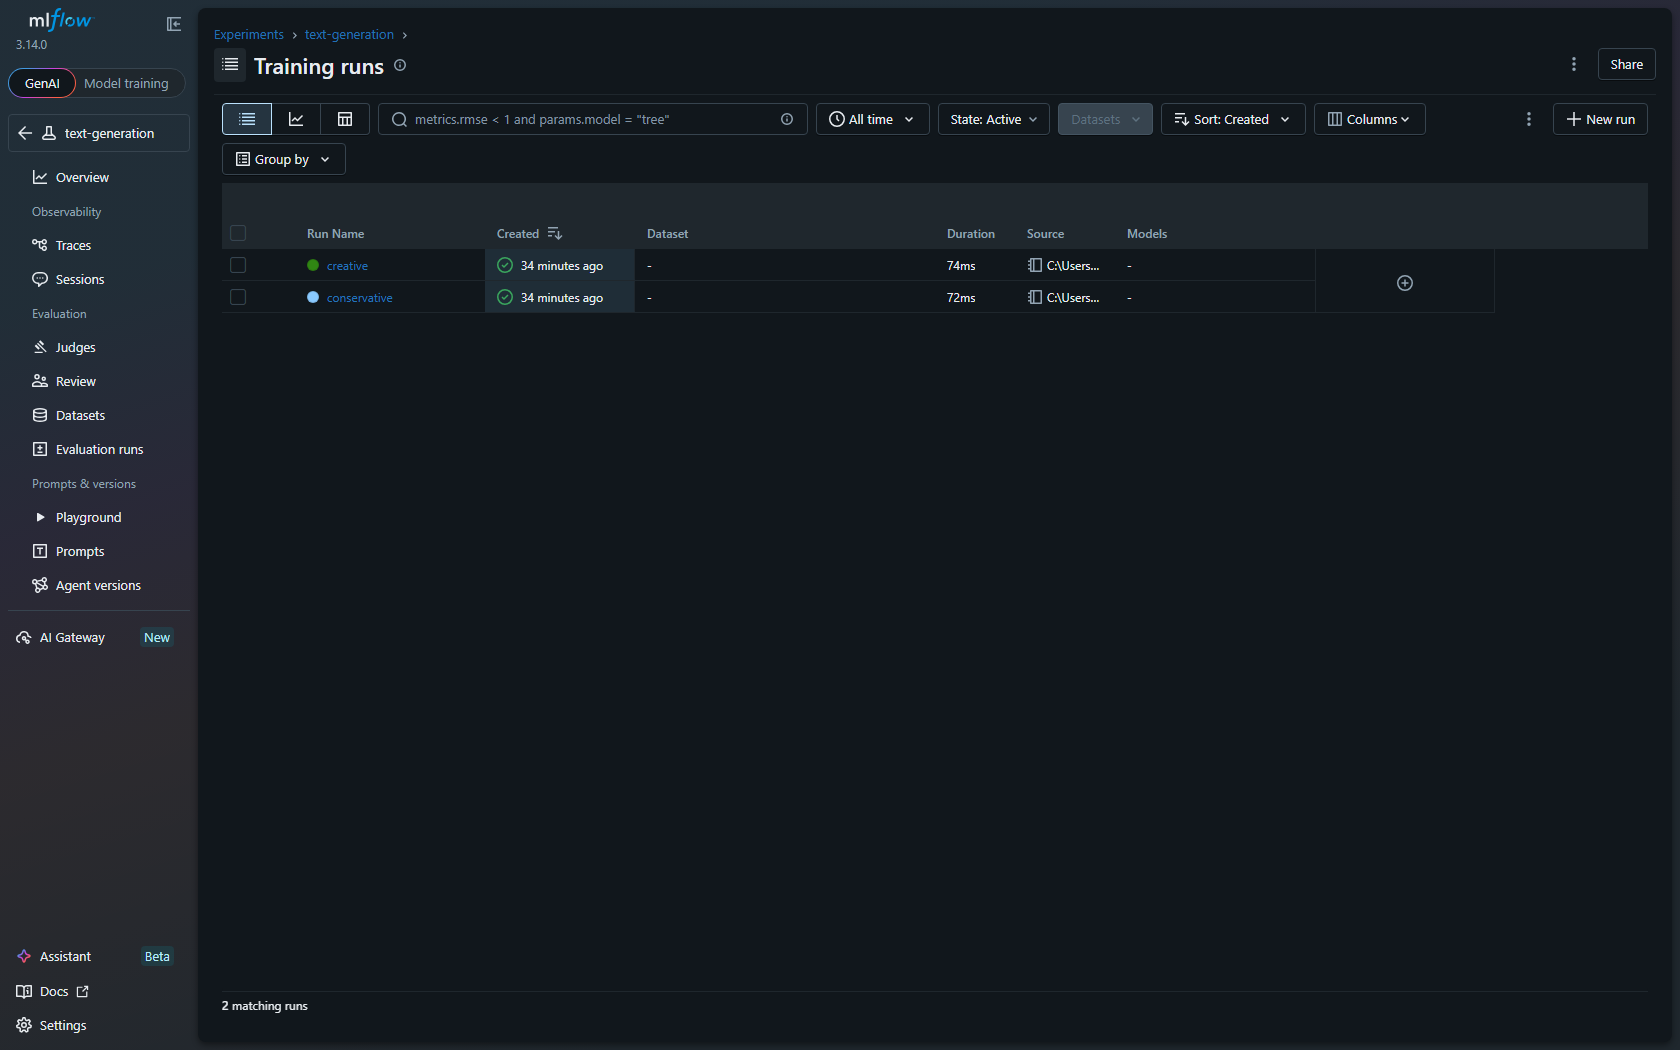
